# Dimensionality reduction analysis

After applying the different clustering algorithms, we now look at ways to improve the obtained results. One way to do so is by applying dimension reduction techniques such as Principal Component Analysis (PCA) and Canonical Correlation Analysis (CCA).


**<font color='red'>PCA:</font>** This method is used to reduced the dimensions of the data. In fact, sometimes we have variables that do not give any information about the data and thus removing these variables can lead to better results.  

**<font color='red'>CCA:</font>** This method is used to detect correlations between different subgroups of data. In fact, sometimes we have variables that are so strongly correlated that reducing the dimensions using linear combinations between the correlated variables can imporove the results
It is **important to note that we will NOT use the labels when applying PCA and CCA.**

___


Therefore, in this part of the project, you will apply both PCA and CCA on the data you chose in the clustering part. Afterwards, you will apply the clustering method that gave the best results in TD2_3 on the reduced dataset you obtained from the PCA step.

**You should send this notebook filled with your results before 11.59pm on Sunday 8 December.**

You must submit it using eCampus, or send a mail to either massinissa.hamidi@univ-evry.fr or clement.bernard@univ-evry.fr.

## Mount Drive

**For google colab users only**

In [7]:
import os
from google.colab import drive

drive.mount('/content/drive')

# Change to the directory to where your files are
os.chdir('drive/My Drive/project_data')



Mounted at /content/drive


## Import Libraries

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering

## Load the dataset, separate data from classes



Load the dataset you are using in your project and separate the data from the class.

**<font color='red'>N.B:</font>** If you have applied some preprocessing steps (missing value replacement, factorize), please used the dataset you obtained after all the steps (you should have saved your dataset in notebook TD2_3.ipynb) without the normalization step.





In [9]:
filename = 'scaled_df.csv'

In [15]:
df_scaled = pd.read_csv(filename)

display(df_scaled.head())


Data Loaded Successfully!
Shape: (3961, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.185352,-0.101889,0.209651,3.041572,-0.039181,0.587571,0.760754,2.482748,-1.289928,-0.355488,-1.470396
1,-0.622262,0.188179,0.046294,-0.887634,0.133981,-1.213933,-0.120433,0.072470,0.689924,-0.003092,-0.895174
2,1.454460,-0.005199,0.536367,0.202669,0.177271,-0.284124,-0.932053,0.451228,0.425944,-0.443587,-0.402127
3,0.416099,-0.488646,-0.117064,0.531817,0.523594,0.703797,1.131781,0.623391,-0.036022,-0.795984,-0.566476
4,-0.737636,0.381558,-1.423927,0.223241,-0.039181,-0.284124,-0.027677,0.382363,-0.102017,-0.179290,-0.813000


## Part 1: Apply PCA


##### We start by scaling the data so that each feature has a single unit variance.  


**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale both continuous and numerical variables.
PCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

In [ ]:
# Use StandardScaler


##### We then instantiate a PCA object.

The main parameter of this method is the max number of components. In this project, we will choose it to be equal to the max number of variables in the data.


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scaled)
X_scaled = pd.DataFrame(X_scaled, columns=df_scaled.columns)
n_components = X_scaled.shape[1]
pca = PCA(n_components=n_components)
pca.fit(X_scaled)

print("Scaling applied and PCA fitted.")
print(f"Total variables: {n_components}")
print(f"PCA components created: {pca.n_components_}")


Scaling applied and PCA fitted.
Total variables: 11
PCA components created: 11


### Interpreting the components

The next step is to choose the number of components to keep.

##### Plot the explained variance of each component using the corrected variance.

extract the Eigenvalues (valeurs propres)

In [20]:
eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

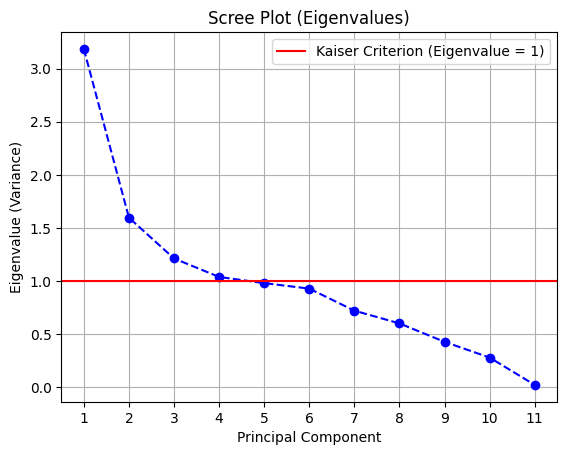

--- Eigenvalues (Variances) ---
Component 1: 3.1843
Component 2: 1.5969
Component 3: 1.2134
Component 4: 1.0393
Component 5: 0.9814
Component 6: 0.9295
Component 7: 0.7222
Component 8: 0.6022
Component 9: 0.4289
Component 10: 0.2810
Component 11: 0.0237


In [22]:
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--', color='b')
plt.title('Scree Plot (Eigenvalues)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.axhline(y=1, color='r', linestyle='-', label='Kaiser Criterion (Eigenvalue = 1)')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()
print("--- Eigenvalues (Variances) ---")
for i, val in enumerate(eigenvalues):
    print(f"Component {i+1}: {val:.4f}")

##### Plot the cumulative variance of the components based on the explained variance ratio.

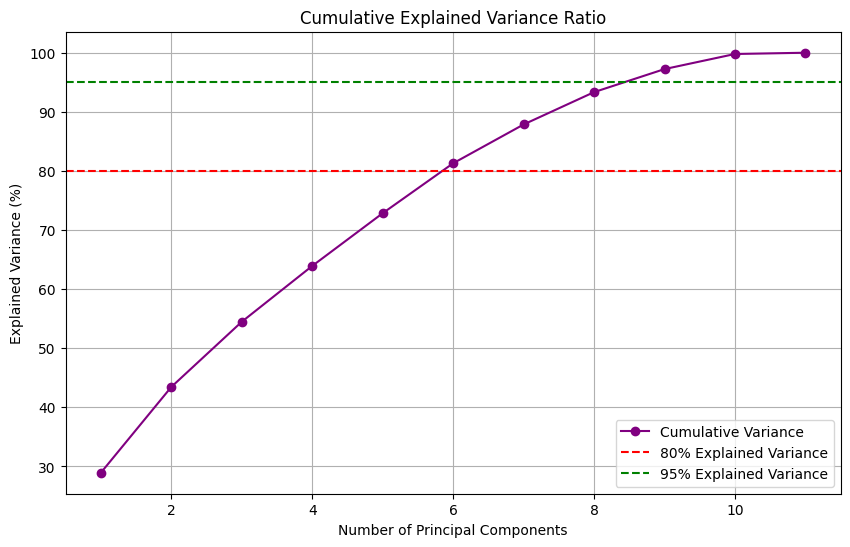

--- Cumulative Variance ---
Components 1 to 1: 28.94% of information
Components 1 to 2: 43.45% of information
Components 1 to 3: 54.48% of information
Components 1 to 4: 63.93% of information
Components 1 to 5: 72.85% of information
Components 1 to 6: 81.30% of information
Components 1 to 7: 87.86% of information
Components 1 to 8: 93.33% of information
Components 1 to 9: 97.23% of information
Components 1 to 10: 99.79% of information
Components 1 to 11: 100.00% of information


In [23]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
         marker='o', linestyle='-', color='purple', label='Cumulative Variance')
plt.axhline(y=80, color='r', linestyle='--', label='80% Explained Variance')
plt.axhline(y=95, color='g', linestyle='--', label='95% Explained Variance')

plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance (%)')
plt.legend(loc='best')
plt.grid(True)
plt.show()
print("--- Cumulative Variance ---")
for i, val in enumerate(cumulative_variance):
    print(f"Components 1 to {i+1}: {val*100:.2f}% of information")

##### How many components will you keep? Explain your choice.

Decision: Keep 4 Components
Explanation: According to the Kaiser Criterion, we should retain principal components with an eigenvalue greater than 1.

Component 1 to 4: Have eigenvalues > 1 (3.18, 1.60, 1.21, 1.04).

Component 5: Has an eigenvalue of 0.98, which is below the threshold.

Therefore, you should choose to keep 4 components. This captures the statistically significant information while discarding the noise (Components 5 through 11).

**Note:** If you do choose to keep all components in your analysis, you do not perform any dimension reduction.

##### Create your reduced dimensionality dataset by only keeping the components you chose to keep in the above question.

In [24]:
n_keep = 4
pca_final = PCA(n_components=n_keep)
X_reduced_array = pca_final.fit_transform(X_scaled)
columns = [f'PC{i+1}' for i in range(n_keep)]
X_reduced = pd.DataFrame(X_reduced_array, columns=columns)
print(f"--- Dimension Reduction Complete ---")
print(f"Kept 4 components (Eigenvalues > 1)")
print(f"Reduced Dataset Shape: {X_reduced.shape}")
display(X_reduced.head())
total_variance_kept = sum(pca.explained_variance_ratio_[:n_keep]) * 100
print(f"\nTotal variance preserved with 4 components: {total_variance_kept:.2f}%")

--- Dimension Reduction Complete ---
Kept 4 components (Eigenvalues > 1)
Reduced Dataset Shape: (3961, 4)


,PC1,PC2,PC3,PC4
0,3.862702,0.511138,0.906204,-1.189948
1,-0.511673,-0.436496,0.345879,1.057328
2,0.284474,1.171489,0.115821,0.240730
3,1.585098,-0.062778,-0.080411,-0.529644
4,0.215305,-0.886144,1.277464,-0.077055



Total variance preserved with 4 components: 63.93%


##### What is the inertia percentage explained by the components you kept *(le pourcentage d’inertie expliquée par le premier axe factoriel)*?

What does it mean?

2. The Cumulative Inertia (All 4 Components)
The Value: 63.93%.Calculation: Sum of the first 4 percentages ($28.94 + 14.51 + 11.03 + 9.45$).

It means that by reducing out dataset from 11 variables down to 4, we have preserved 64% of the original information.

We have discarded 36% of the data, which is considered "noise" or redundant information.

##### Calculate the contribution of the first individual to the first component *(la contribution du premier individu au premier axe factoriel)*

Formula for ContributionThe contribution of an individual $i$ to a principal component (axis) $k$ is calculated as:.

$$\text{Contribution}_{i,k} = \frac{\text{Score}_{i,k}^2}{n \times \lambda_k}$$

Where:


---



---


$\text{Score}_{i,k}$: The coordinate of the individual on the axis (from X_reduced).

$n$: The total number of individuals (rows).

$\lambda_k$: The eigenvalue (variance) of the axis.

In [26]:
coordinate = X_reduced.iloc[0, 0]
eigenvalue = pca_final.explained_variance_[0]
n = len(df_scaled)
contribution = (coordinate ** 2) / (n * eigenvalue)
print("--- Contribution Analysis ---")
print(f"Coordinate (Score) of 1st Individual: {coordinate:.4f}")
print(f"Eigenvalue of PC1:                    {eigenvalue:.4f}")
print(f"Total Individuals (n):                {n}")
print("-" * 30)
print(f"Contribution (Raw):                   {contribution:.6f}")
print(f"Contribution (Percentage):            {contribution * 100:.4f}%")

--- Contribution Analysis ---
Coordinate (Score) of 1st Individual: 3.8627
Eigenvalue of PC1:                    3.1843
Total Individuals (n):                3961
------------------------------
Contribution (Raw):                   0.001183
Contribution (Percentage):            0.1183%




Interpretation:

Average Contribution: In a perfectly balanced dataset, every individual would contribute $\frac{1}{3961} \approx 0.025\%$.

Result: This individual contributes $0.1183\%$.

Conclusion: This individual contributes about 4.7 times more than the average wine ($\frac{0.1183}{0.025} \approx 4.73$).

This means it is a relatively significant data point in defining the "Body/Density" axis (PC1), likely because it has values (alcohol, density, etc.) that are somewhat far from the average.


##### Calculate the quality of representation of this individual in the map made of the first factorial axis *(la qualité de représentation de cet individu dans le plan constitué du premier axe factoriel)*.

What can you deduce?

In [27]:
dist_sq = np.sum(X_scaled.iloc[0]**2)

# 3. Calculate Cos^2 (Quality)
cos2 = (coordinate ** 2) / dist_sq

print("--- Quality of Representation (Cos^2) ---")
print(f"Coordinate^2 on PC1:  {coordinate**2:.4f}")
print(f"Total Distance^2:     {dist_sq:.4f}")
print("-" * 30)
print(f"Quality (Cos^2) on PC1: {cos2:.4f}")

--- Quality of Representation (Cos^2) ---
Coordinate^2 on PC1:  14.9205
Total Distance^2:     20.3818
------------------------------
Quality (Cos^2) on PC1: 0.7320


Deduction

The value: $0.7320$ (or 73.2%).

Interpretation:

High Accuracy: The first principal component (PC1) alone accounts for 73.2% of the information regarding this specific individual. This is a very high number (close to 1).

Low Distortion: This means that when we project this wine onto the PC1 axis, the position we see is not a distortion.
The point lies physically very close to the axis in the multi-dimensional space.

Characterization: Since PC1 represents the "Body/Density" trade-off (Alcohol vs. Sugar/Density), we can deduce that this specific wine is primarily defined by its body and density characteristics. Factors like acidity (PC2) are secondary for this specific individual.

### Variable representation

#### Compute the correlation between the principal components and the variables

##### Print the correlation matrix.

$$\text{Correlation} = \text{Eigenvector} \times \sqrt{\text{Eigenvalue}}$$

--- Correlation Matrix (Variables vs Principal Components) ---


,PC1,PC2,PC3,PC4
fixed acidity,0.272730,0.753132,-0.061097,0.003125
volatile acidity,0.047772,-0.080046,0.740442,0.171526
citric acid,0.271080,0.485291,-0.508301,0.145082
residual sugar,0.753216,-0.030978,0.222755,-0.285535
chlorides,0.378250,0.037532,0.119608,0.682443
free sulfur dioxide,0.549890,-0.329092,-0.341386,-0.344195
total sulfur dioxide,0.743779,-0.284585,-0.135924,-0.095741
density,0.913718,-0.016560,0.141925,0.006320
pH,-0.203465,-0.730744,-0.159726,0.136738
sulphates,0.084654,-0.241762,-0.388633,0.507624


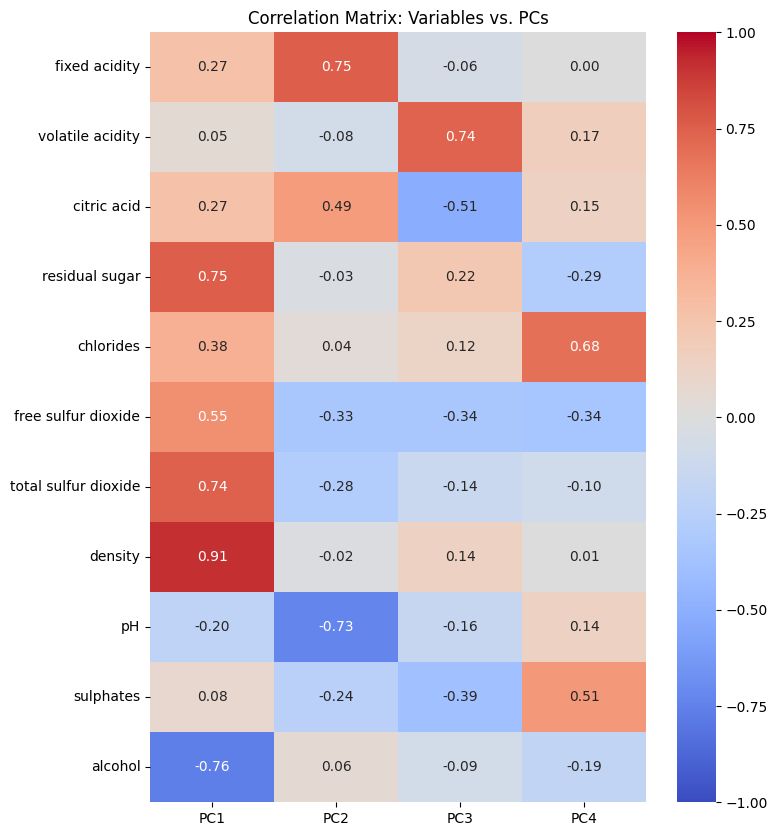

In [29]:
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# 2. Create a clean DataFrame
loading_matrix = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)],
    index=df_scaled.columns
)

# 3. Print the Matrix
print("--- Correlation Matrix (Variables vs Principal Components) ---")
display(loading_matrix)

# 4. Optional: Visual Heatmap (Makes it easier to read)
plt.figure(figsize=(8, 10))
sns.heatmap(loading_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Variables vs. PCs')
plt.show()





##### Plot the correlation circle

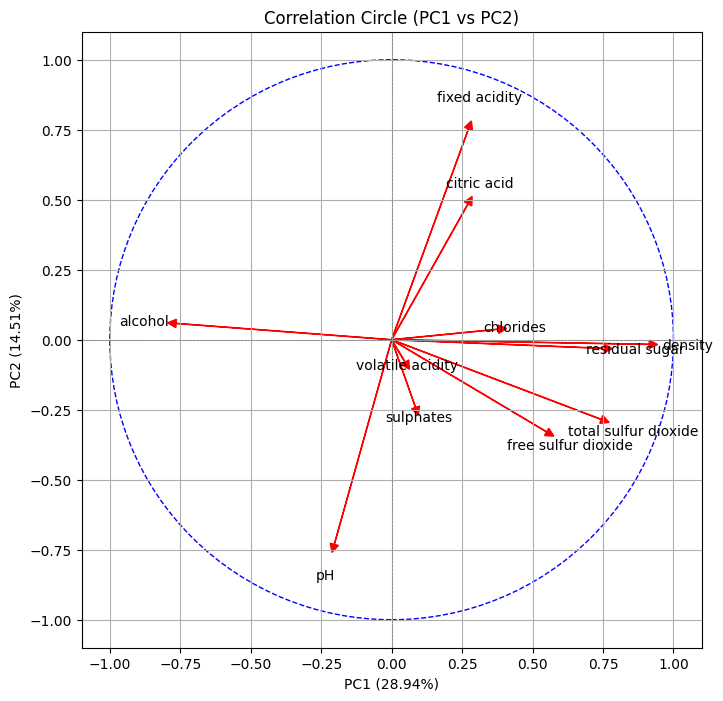

In [30]:
def plot_correlation_circle(pca, feature_names, x_comp=0, y_comp=1):
    # 1. Get the correlations (Loadings)
    # We use the formula: Eigenvector * Sqrt(Eigenvalue)
    # This matches the "Correlation Matrix" values you just calculated
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    # 2. Create the Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the Unit Circle (Correlation = 1)
    circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
    ax.add_artist(circle)

    # Plot the Arrows
    # x_comp and y_comp are indices (0=PC1, 1=PC2)
    for i, (x, y) in enumerate(zip(loadings[:, x_comp], loadings[:, y_comp])):
        # Draw Arrow
        ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, fc='red', ec='red')

        # Draw Label (with a slight offset for readability)
        # We multiply by 1.1 to push the text just outside the arrow tip
        ax.text(x * 1.15, y * 1.15, feature_names[i], color='black', ha='center', va='center')

    # 3. formatting
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
    plt.xlabel(f'PC{x_comp+1} ({pca.explained_variance_ratio_[x_comp]*100:.2f}%)')
    plt.ylabel(f'PC{y_comp+1} ({pca.explained_variance_ratio_[y_comp]*100:.2f}%)')
    plt.title(f'Correlation Circle (PC{x_comp+1} vs PC{y_comp+1})')
    plt.grid(True)
    plt.show()

# --- EXECUTION ---
# Using the pca_final model (4 components)
feature_names = df_scaled.columns
plot_correlation_circle(pca_final, feature_names, 0, 1) # Plot PC1 vs PC2

##### Interpret the obtained results

The first two principal components explain approximately 43.45% of the total variance.

PC1 (28.94%) appears to represent the 'Body' or 'Density' of the wine. It shows a strong opposition between alcohol (on the negative side) and density/residual sugar (on the positive side). This confirms the physicochemical relationship where higher sugar content increases density, while higher alcohol content decreases it.

PC2 (14.51%) clearly represents the 'Acidity' profile. It is defined by fixed acidity and citric acid on the positive side, opposing pH on the negative side. This captures the chemical balance of the wine, separating high-acid wines (top) from low-acid/high-pH wines (bottom)

## Applying clustering on the newly created dataset.

Recall in TD2_3.ipynb, you applied different clustering algorithms on your dataset and analyzed which method gave the best results on your dataset.

##### Apply this clustering method to the dataset you obtained after applying PCA and performing dimension reduction.

in TD2_3.ipnyb we got the best result with the spectral clustering with k = 2 , so we are gonna apply it to dataset after applying PCA

In [32]:
n_clusters = 2

# 1. Initialize the Spectral Clustering Model
# affinity='nearest_neighbors' is usually best for detecting complex shapes
model = SpectralClustering(n_clusters=n_clusters,
                           affinity='nearest_neighbors',
                           assign_labels='kmeans',
                           random_state=42,
                           n_jobs=-1)

# 2. Fit and Predict
# We apply this strictly to 'X_reduced' (our 4 PCA components)
print(f"Applying Spectral Clustering with {n_clusters} clusters...")
labels = model.fit_predict(X_reduced)

# 3. Save the results
# We add the cluster labels back to our X_reduced dataframe to visualize them
X_reduced_clustered = X_reduced.copy()
X_reduced_clustered['Cluster'] = labels

print("✅ Clustering Complete.")
print(X_reduced_clustered['Cluster'].value_counts())

Applying Spectral Clustering with 2 clusters...
✅ Clustering Complete.
Cluster
1    2624
0    1337
Name: count, dtype: int64


##### Using the same metrics you used in TD2_3.ipynb, compare the results obtained with this method to the real classes.

##### In your opinion, did dimensionality reduction help you in getting better results or not?

## Part 2: Apply CCA

Next steps:
   - Apply CCA /!\ Don't forget to split the dataset into two groups,i.e., p=3 and q=3
   - Analyze the correlation circle *(graphe des variables)*
   - Analyze the observation graph *(graphe des individus)*

**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale use continuous and numerical variables.
CCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

### Choice of the two groups

##### Show the correlation matrix of the data

##### Split your data into two groups p and q

##### How did you choose your two groups?

### Apply CCA

CCA with scikit-learn uses a very similar process to other preprocessing functions that come with scikit-learn. We instantiate a CCA object, find the  components (linear combinations of the variables) using the fit method, then apply the dimensionality reduction by calling transform().

We can also specify how many components we want to keep when creating the CCA object.

Check the scikit-learn documentation for CCA. Do you need to use the scaled or unscaled data to apply CCA?



##### Apply CCA

##### Print the first two components

##### Print the correlation matrix between the first two components

##### What can you conclude?

### Results visualization and interpretation

#### Variable representation

##### Compute the correlation between the components and the variables

[*aide: utiliser les matrices centrées-réduites*]

##### Show the correlation circle

##### Interpret the obtained results

#### Individual visualization

##### Show the individuals representation

##### Interpret the obtained results

### CCA Conclusion
Based on your visualizations, do you think it would be useful to use the CCA results to reduce the dimensionality of your dataset before applying some form of clustering method, like you did with PCA? Why / why not?